<a href="https://colab.research.google.com/github/Dhanasree07/capstone_project/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
last

In [ ]:
# 1. IMPORT LIBRARIES
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import time

from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier

In [ ]:
# 2. LOAD DATASET
# -----------------------------
train_df = pd.read_csv("/content/UNSW_NB15_training-set.csv")
test_df  = pd.read_csv("/content/UNSW_NB15_testing-set.csv")

# Drop identifier column if present
for col in ['id']:
    if col in train_df.columns:
        train_df.drop(columns=[col], inplace=True)
        test_df.drop(columns=[col], inplace=True)

print("Training data shape:", train_df.shape)
print("Testing data shape :", test_df.shape)

Training data shape: (82332, 44)
Testing data shape : (175341, 44)


In [ ]:
# 3. DATA CLEANING
# -----------------------------
# Replace infinite values with NaN
train_df.replace([np.inf, -np.inf], np.nan, inplace=True)
test_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing numeric values with median
train_df.fillna(train_df.median(numeric_only=True), inplace=True)
test_df.fillna(train_df.median(numeric_only=True), inplace=True)

In [ ]:
# 4. FEATURE–TARGET SPLIT
# -----------------------------
X_train = train_df.drop(columns=['label', 'attack_cat'])
y_train = train_df['label']        # 0 = Normal, 1 = Attack

X_test = test_df.drop(columns=['label', 'attack_cat'])
y_test = test_df['label']

In [ ]:
# 5. ENCODE CATEGORICAL FEATURES
# -----------------------------
cat_cols = X_train.select_dtypes(include='object').columns
print("Categorical columns:", list(cat_cols))

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

Categorical columns: ['proto', 'service', 'state']


In [ ]:
# 6. OUTLIER HANDLING (CLIPPING)
# -----------------------------
# UNSW-NB15 contains extreme values; clipping stabilizes learning
for col in X_train.columns:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)

In [ ]:
# 7. FEATURE SELECTION
# -----------------------------
base_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

base_model.fit(X_train, y_train)

selector = SelectFromModel(base_model, threshold="median", prefit=True)
X_train = selector.transform(X_train)
X_test = selector.transform(X_test)

print("Selected features:", X_train.shape[1])

Selected features: 21


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [ ]:
# 8. FINAL XGBOOST MODEL
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=600,
    max_depth=9,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.2,
    min_child_weight=1,
    scale_pos_weight=neg / pos,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=0.2, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=600,
              n_jobs=-1, num_parallel_tree=None, ...)


Model Accuracy: 0.9008731557365363

Classification Report:

              precision    recall  f1-score   support

      Normal       0.77      0.98      0.86     56000
      Attack       0.99      0.86      0.92    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.89    175341
weighted avg       0.92      0.90      0.90    175341



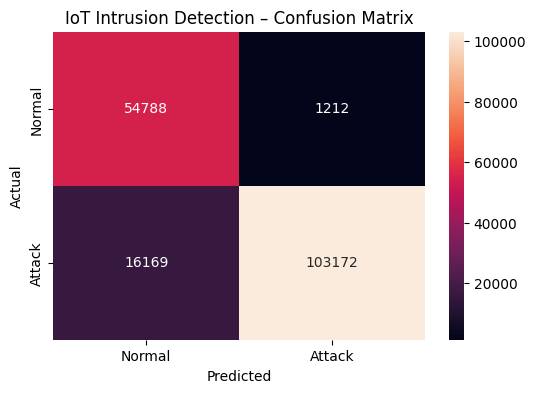

In [ ]:
# 9. MODEL EVALUATION
# -----------------------------
y_pred = model.predict(X_test)

print("\nModel Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["Normal", "Attack"],
            yticklabels=["Normal", "Attack"])
plt.title("IoT Intrusion Detection – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

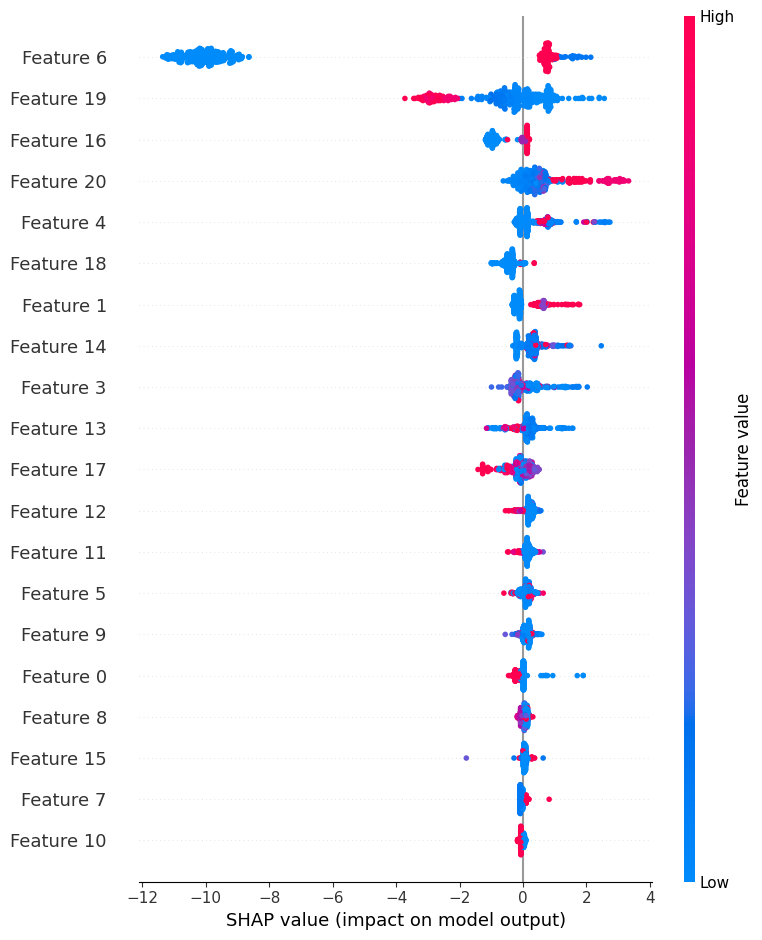

In [ ]:
# 10. EXPLAINABLE AI USING SHAP
# -----------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:500])

shap.summary_plot(shap_values, X_test[:500], show=True)

In [ ]:
# 11. REAL-TIME IOT SIMULATION
# -----------------------------
print("\nStarting the IoT Intrusion Detection (Simulation)...\n")

iot_devices = [
    "Temperature Sensor",
    "Smart Light",
    "Smart Camera",
    "Wearable Device",
    "IoT Gateway"
]

for i in range(10):
    device = np.random.choice(iot_devices)
    sample = X_test[i].reshape(1, -1)
    pred = model.predict(sample)[0]

    status = "Attack" if pred == 1 else "Normal"
    print(f"Device: {device} → Detected: {status}")

    time.sleep(0.5)


Starting the IoT Intrusion Detection (Simulation)...

Device: Temperature Sensor → Detected: Attack
Device: Wearable Device → Detected: Attack
Device: Temperature Sensor → Detected: Attack
Device: Smart Light → Detected: Attack
Device: Temperature Sensor → Detected: Normal
Device: Smart Camera → Detected: Normal
Device: Smart Light → Detected: Normal
Device: Smart Camera → Detected: Normal
Device: Temperature Sensor → Detected: Normal
Device: IoT Gateway → Detected: Normal



Model Accuracy Comparison:
               Model  Accuracy
0   Baseline XGBoost  0.902778
1  Optimized XGBoost  0.900873


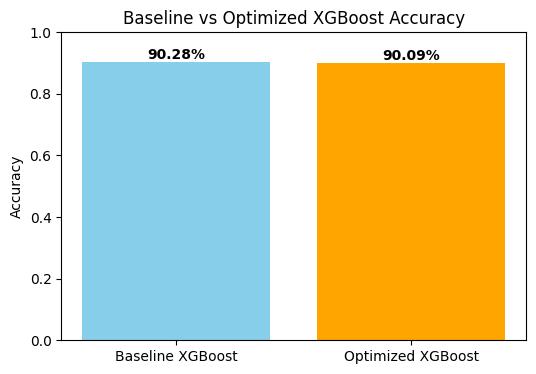

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# 1. Baseline XGBoost Model
# -----------------------------
baseline_model = XGBClassifier(
    n_estimators=200,  # default baseline
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
acc_baseline = accuracy_score(y_test, y_pred_baseline)

# -----------------------------
# 2. Optimized XGBoost Model
# -----------------------------
optimized_model = XGBClassifier(
    n_estimators=600,
    max_depth=9,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.2,
    min_child_weight=1,
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)
optimized_model.fit(X_train, y_train)
y_pred_opt = optimized_model.predict(X_test)
acc_opt = accuracy_score(y_test, y_pred_opt)

# -----------------------------
# 3. Create Table
# -----------------------------
accuracy_table = pd.DataFrame({
    'Model': ['Baseline XGBoost', 'Optimized XGBoost'],
    'Accuracy': [acc_baseline, acc_opt]
})
print("\nModel Accuracy Comparison:")
print(accuracy_table)

# -----------------------------
# 4. Bar Plot
# -----------------------------
plt.figure(figsize=(6,4))
plt.bar(accuracy_table['Model'], accuracy_table['Accuracy'], color=['skyblue', 'orange'])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Baseline vs Optimized XGBoost Accuracy")
for i, v in enumerate(accuracy_table['Accuracy']):
    plt.text(i, v + 0.01, f"{v:.2%}", ha='center', fontweight='bold')
plt.show()


In [ ]:
# Training accuracy
y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

# Testing accuracy
y_test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy: {test_acc:.2%}")


Training Accuracy: 98.88%
Testing Accuracy: 90.09%


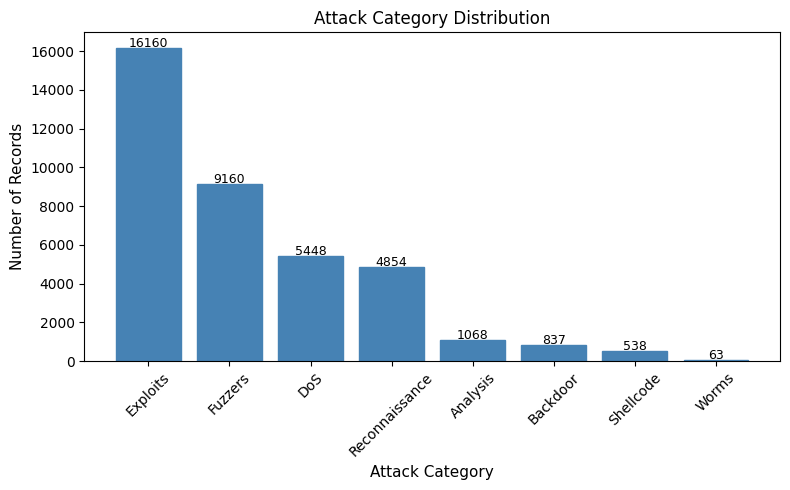

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("UNSW_NB15.csv")   # update filename if required

# Count attack categories (excluding Normal)
attack_counts = df[df['attack_cat'] != 'Normal']['attack_cat'].value_counts()

# Plot bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(attack_counts.index, attack_counts.values)

# Add colors
plt.xticks(rotation=45)
for bar in bars:
    bar.set_color('steelblue')

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50,
             int(yval), ha='center', fontsize=9)

# Labels and title
plt.xlabel("Attack Category", fontsize=11)
plt.ylabel("Number of Records", fontsize=11)
plt.title("Attack Category Distribution", fontsize=12)

plt.tight_layout()
plt.show()
